In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Análises com o modelo boruta selecionado

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install shap
!pip install xgboost==3.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 4.6 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.4.1
    Uninstalling xgboost-3.4.1:
      Successfully uninstalled xgboost-3.4.1


In [ ]:
# Abrindo banco de dados

In [ ]:
#Definindo semente

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install catboost
!pip install shap
#!pip install xgboost
!pip install lightgbm
!pip install boruta
!pip install tabpfn
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.2/771.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37368 sha256=ab9adab5af99bfdf4078630a3f5f373711623630f403dd568a7cec138e300eef
  Stored in directory: /root/.cache/pip/wheels/ec/b5/10/93c91bf324e855f115998634a7f6091b62d7a6a32d6e62c05b
Successfully built pycalib


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
#Definindo semente

In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
import pandas as pd

###Lendo dataframes

In [ ]:
#Import da base de treino e teste base 1
df_train1= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_treino_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test1 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/dados_teste_xgb1boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

#Import da base de treino e teste base2
df_train2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_treino_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/dados_teste_cat2boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

#Import da base de treino e teste base 4
df_train4 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")
df_test4 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/dados_treino_cat3boruta_rj_2015_2025.csv",
                        encoding='latin1', sep=",")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier

# =======================
# Separando features e target
# =======================
X_train_novo1 = df_train1.drop(columns="cura")
y_train1 = df_train1["cura"]
X_test_novo1 = df_test1.drop(columns="cura")
y_test1 = df_test1["cura"]

X_train_novo2 = df_train2.drop(columns="cura")
y_train2 = df_train2["cura"]
X_test_novo2 = df_test2.drop(columns="cura")
y_test2 = df_test2["cura"]

X_train_novo4 = df_train4.drop(columns="cura")
y_train4 = df_train4["cura"]
X_test_novo4 = df_test4.drop(columns="cura")
y_test4 = df_test4["cura"]

In [ ]:
import joblib

# =======================
# Modelos já carregados
# =======================

# Etapa 1
data1 = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa1/best_model_xgb_novo.pkl")
xgb_novo1 = data1["model_xgb_novo"]

# Etapa 2
data2 = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa2/best_model_cat_novo.pkl")
cat_novo2 = data2["model_cat_novo"]

# Etapa 4
data4 = joblib.load("/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Etapa3/best_model_cat_novo.pkl")
cat_novo4 = data4["model_cat_novo"]

###Shapley

In [ ]:
!pip install shap -q

import shap
import matplotlib.pyplot as plt
import numpy as np

###Etapa1

In [ ]:
# Dicionário com os nomes antigos e os novos nomes
colunas_renomeadas = {
    'bacilosc_e_9.0': 'unkn_diag_baci',
    'bacilosc_e_3.0': 'not_perf_diag_baci',
    'bacilosc_2_9.0': 'unkn_2nd_baci',
    'bacilosc_4_9.0': 'unkn_4th_baci',
    'bacilosc_2_2.0': 'neg_2nd_baci',
    'bacilosc_2_3.0': 'not_perf_2nd_baci',
    'bacilosc_4_2.0': 'neg_4th_baci',
    'bacilosc_4_3.0': 'not_perf_4th_baci',
    'bacilosc_e_2.0': 'neg_diag_baci',
    'bacilosc_4_1.0': 'pos_4th_baci',
    'cultura_es_2.0': 'neg_culture',
    'cultura_es_1.0': 'pos_culture',
    'cultura_es_3.0': 'in_prog_culture',
    'cultura_es_4.0': 'not_perf_culture',
    'cs_sexo_1.0': 'male',
    'cs_sexo_0.0': 'female',
    'escola_faixa_1.0': 'study-years_>5',
    'escola_faixa_9.0': 'unkn_study-years',
    'faixa_etaria_0.0': '0-19 yo',
    'faixa_etaria_1.0': '20-39 yo',
    'faixa_etaria_2.0': '40-59 yo',
    'faixa_etaria_3.0': '60+ yo',
    'faixa_etaria_9.0': 'unkn_age',
    'agravdroga_1.0': 'drug_user',
    'agravdroga_0.0': 'no_drug_user',
    'agravdroga_9.0': 'unkn_drug_user',
    'agravalcoo_1.0': 'alcohol_user',
    'agravalcoo_0.0': 'no_alcohol_user',
    'agravalcoo_9.0': 'unkn_alcohol_user',
    'cs_raca_1.0': 'white',
    'cs_raca_2.0': 'black',
    'tratsup_at_1.0': 'treatm_support',
    'tratsup_at_0.0': 'no_treatm_support',
    'tratsup_at_9.0': 'unkn_treatm_support',
    'pop_rua_1.0': 'homeless',
    'pop_liber_1.0': 'incarcerated',
    'pop': 'population',
    'agravdiabe_1.0': 'diabetes',
    'agravdiabe_0.0': 'no_diabetes',
    'agravdoenca_1.0': 'other_diseases',
    'agravtabac_1.0': 'smoking',
    'agravtabac_0.0': 'no_smoking',
    'agravdoenca_0.0': 'no_other_diseases',
    'agravtabac_9.0': 'unkn_smoking',
    'agravdoenc_1.0':'other_diseases',
    'agravdoenc_0.0': 'no_other_diseases',
    'agravdoenc_9.0': 'unkn_other_diseases',
    'agravdiabe_9.0': 'unkn_diabetes',
    'raiox_tora_1.0': 'suggest_X-ray',
    'raiox_tora_2.0': 'normal_X-ray',
    'raiox_tora_4.0': 'not_perf_X-ray',
    'raiox_tora_9.0': 'unkn_X-ray',
    'tempo_diag_trat_14_0.0': 'no_delay_treatment',
    'tempo_diag_trat_14_1.0': 'delay_treatment',
    'benef_gov_0.0': 'no_financ_support',
    'benef_gov_1.0': 'financ_support'
}

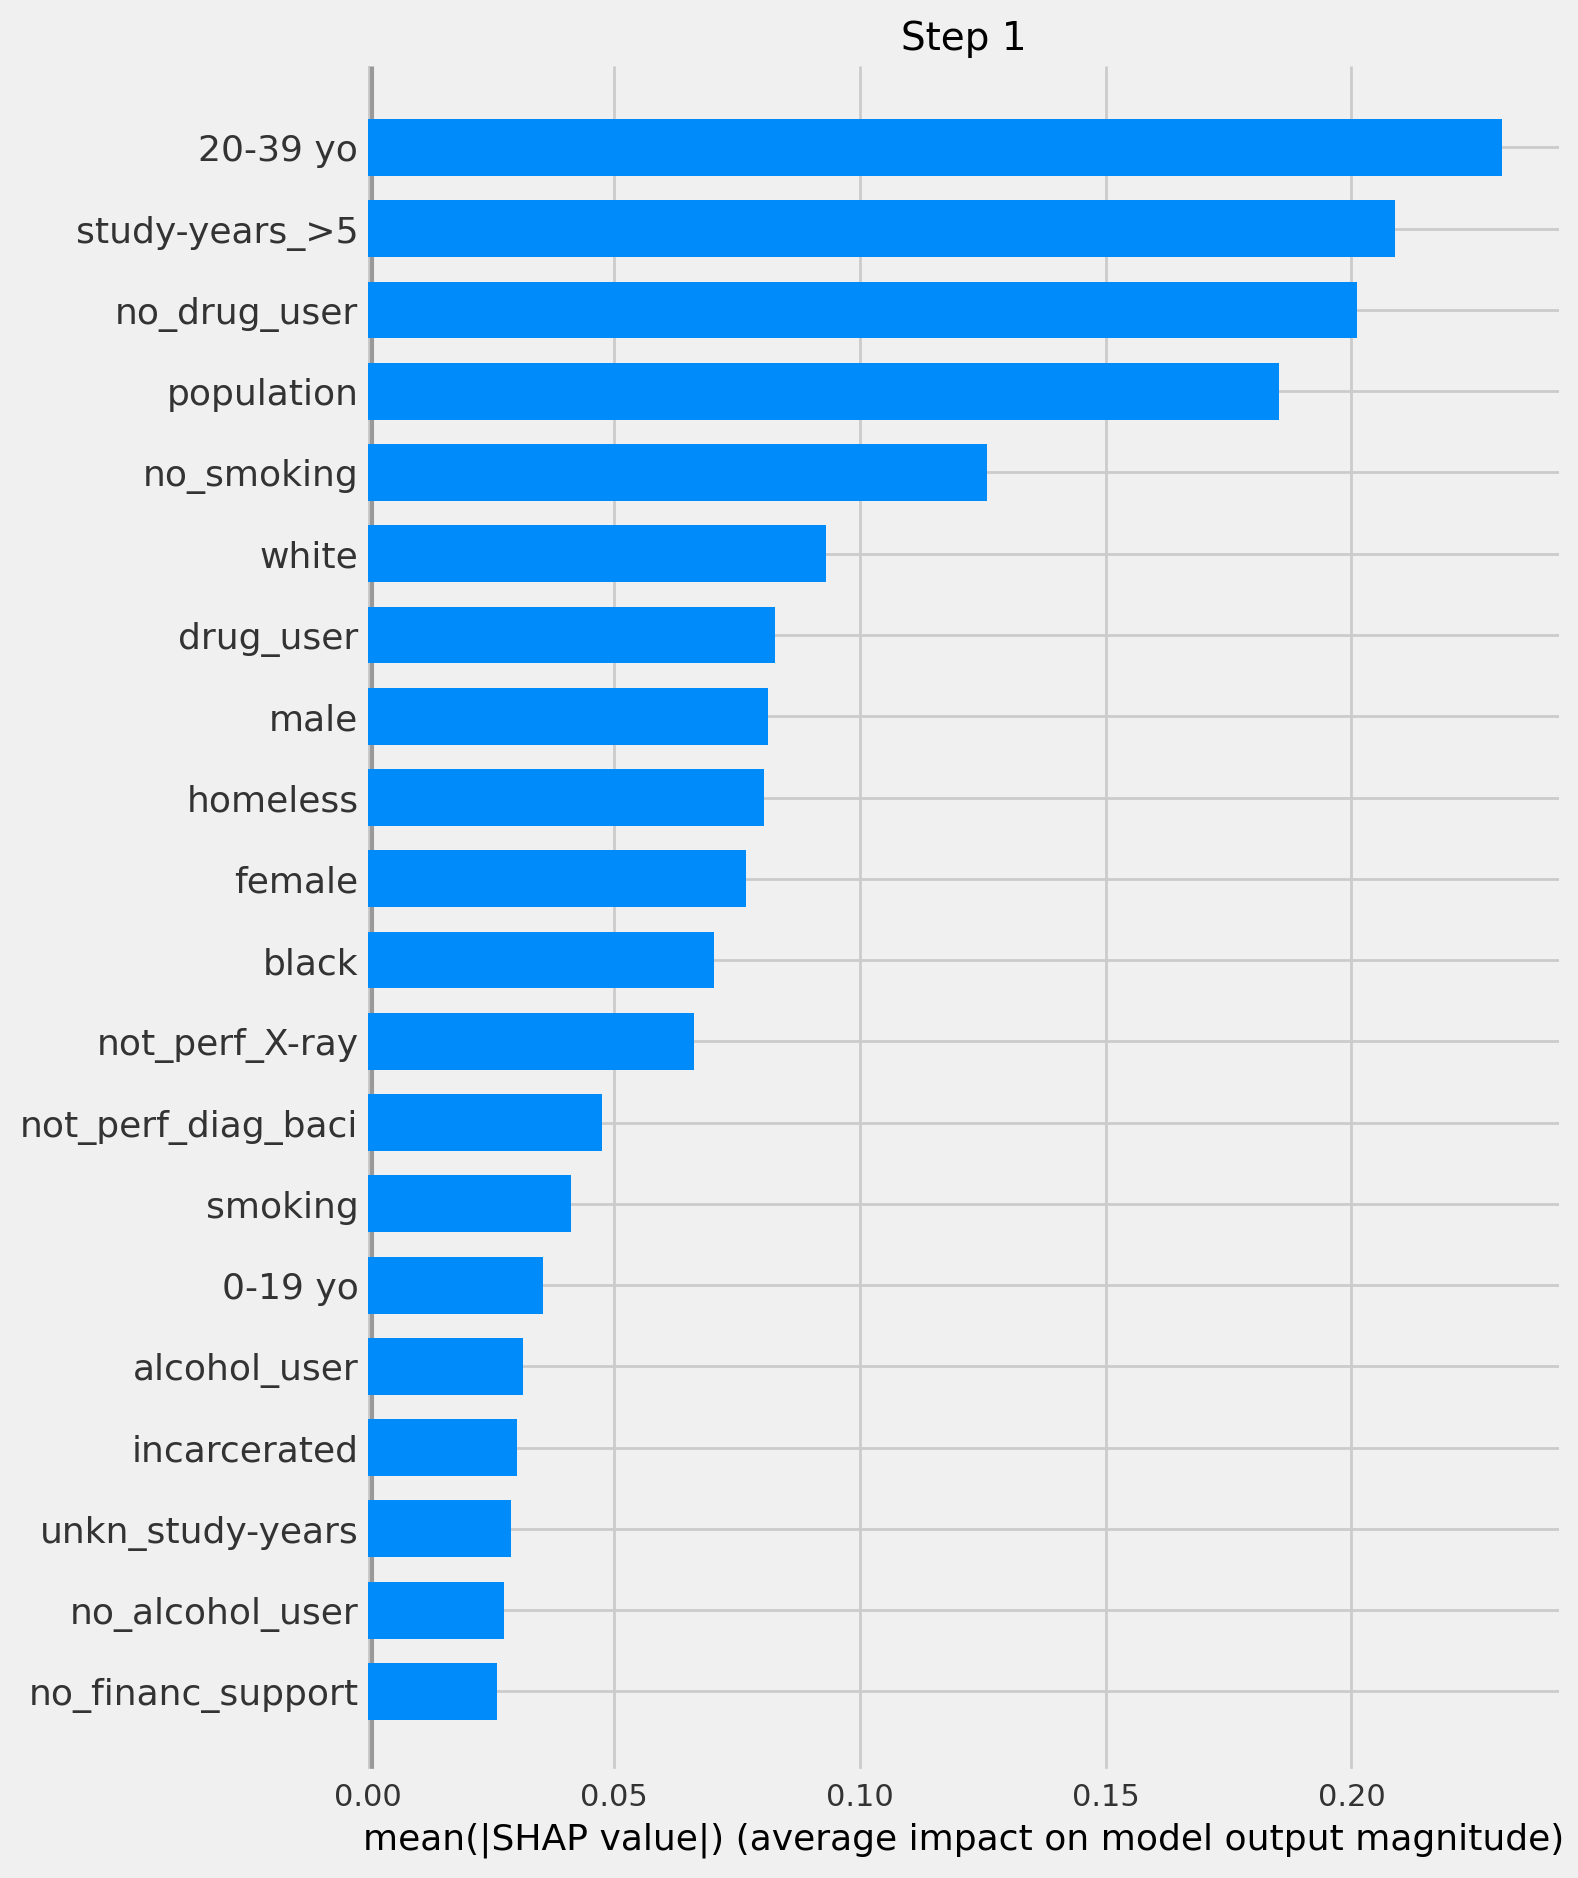

In [ ]:
import matplotlib.pyplot as plt
import shap

# =====================================================
# Renomear colunas do X_test
# =====================================================

X_test_novo1_shap = X_test_novo1.copy()

X_test_novo1_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)


# =====================================================
# Explainer SHAP
# =====================================================

explainer_xgb = shap.TreeExplainer(
    xgb_novo1
)


# Valores SHAP
shap_values_xgb = explainer_xgb.shap_values(
    X_test_novo1
)


# =====================================================
# Summary plot
# =====================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values_xgb,
    X_test_novo1_shap,
    plot_type="bar",
    show=False
)


plt.title(
    "Step 1",
    fontsize=14
)

plt.tight_layout()


# =====================================================
# Salvar TIFF 300 dpi
# =====================================================

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step1_Global.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

###Etapa2

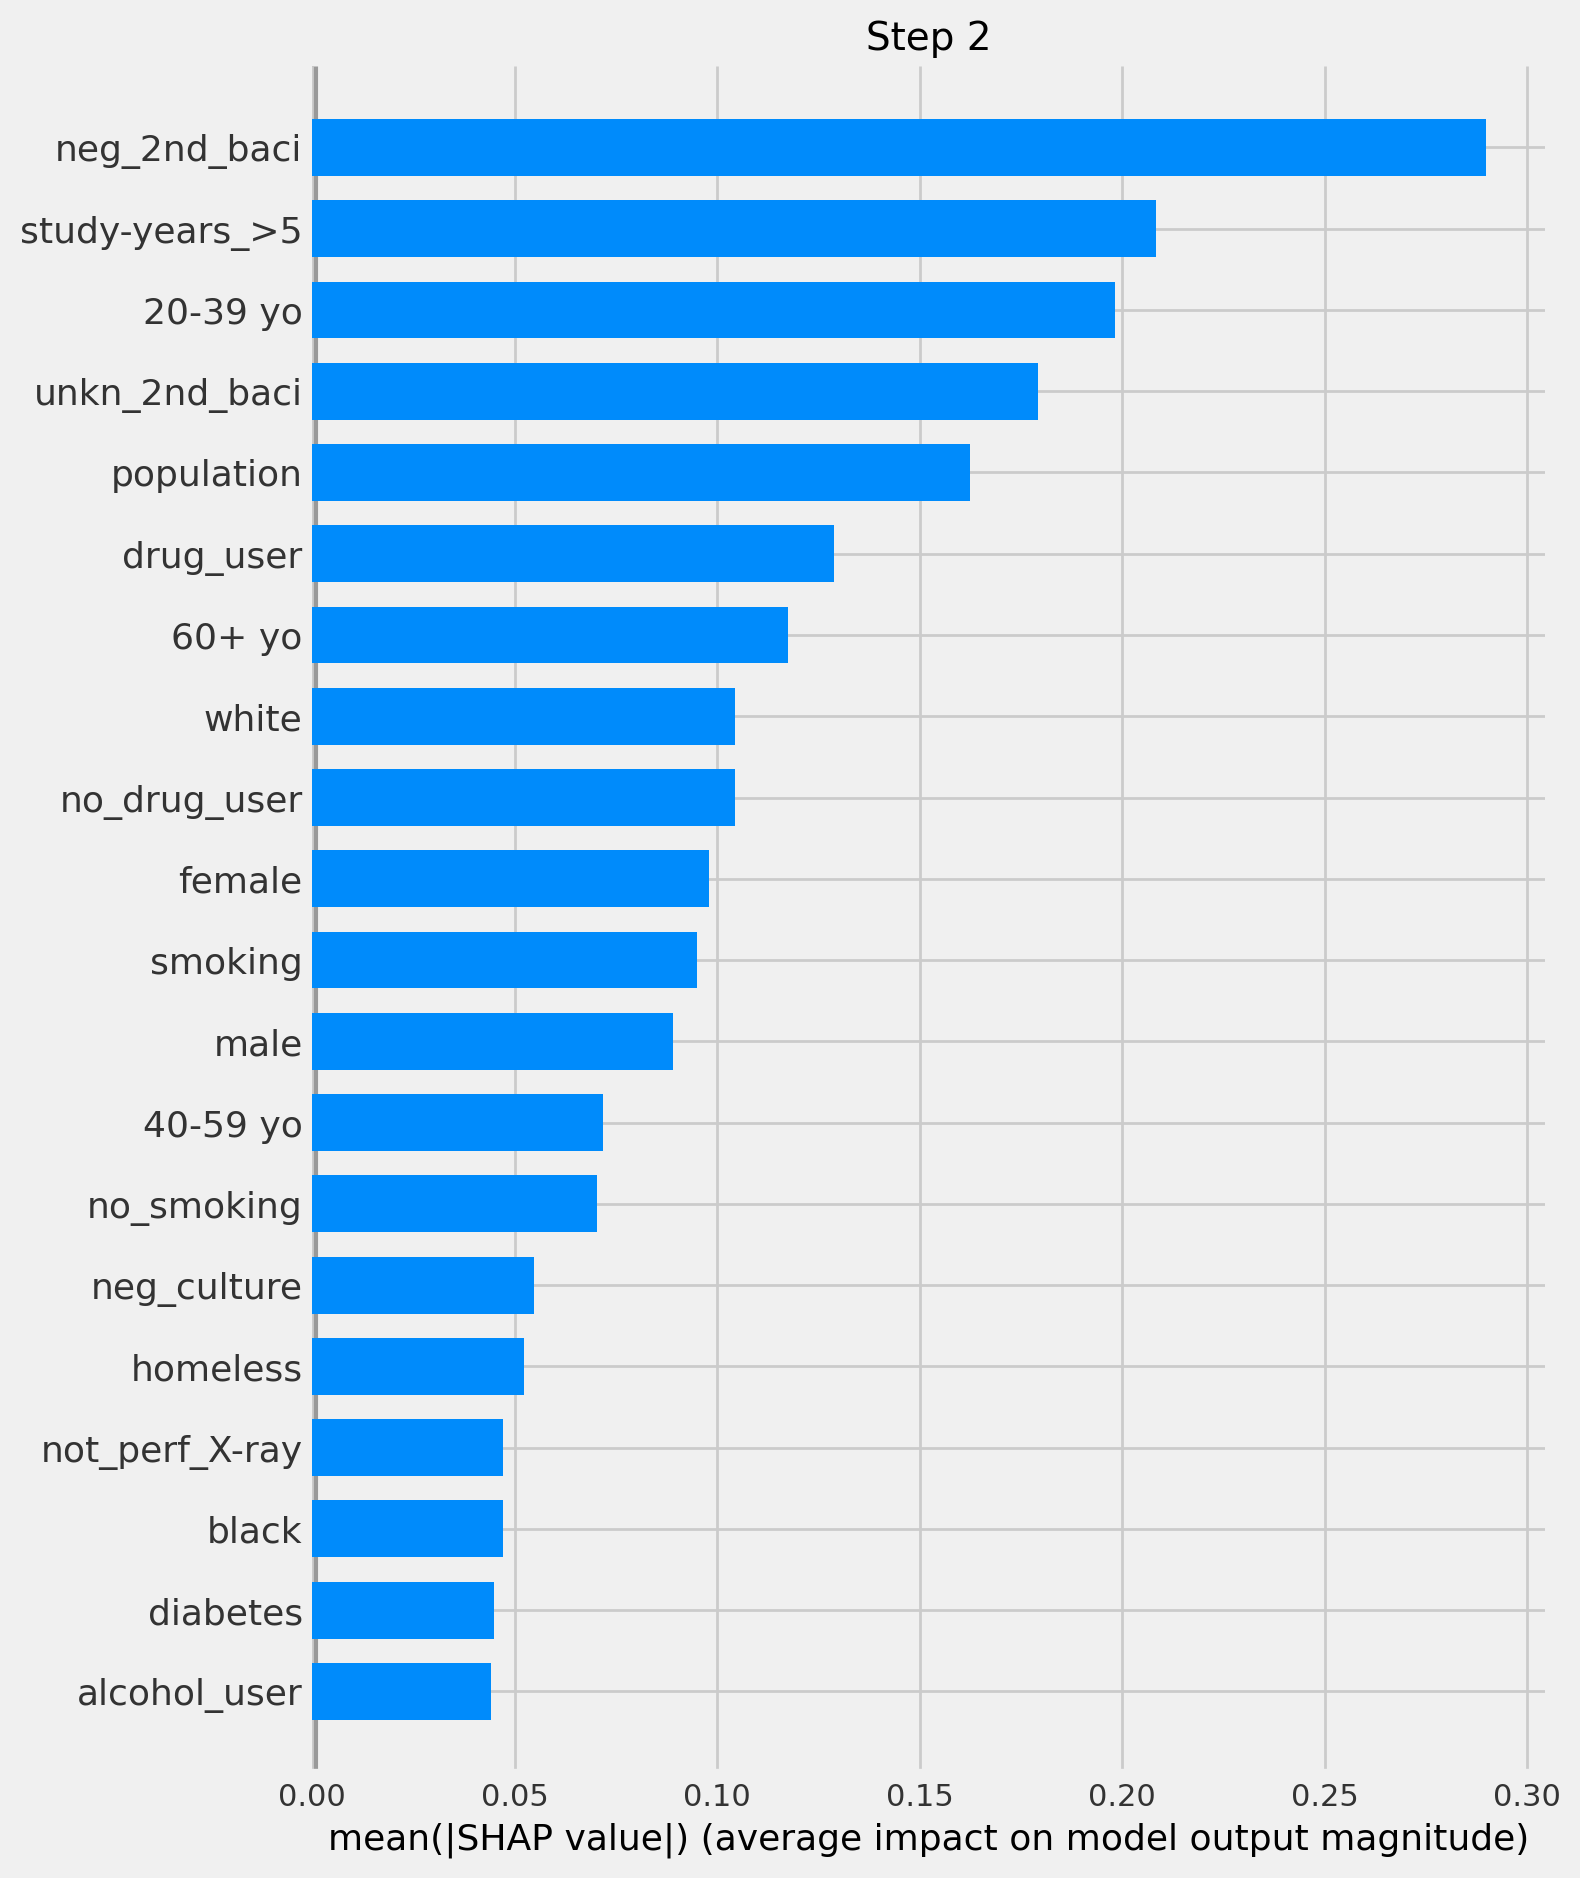

In [ ]:
import matplotlib.pyplot as plt
import shap

# =====================================================
# Renomear colunas do X_test
# =====================================================

X_test_novo2_shap = X_test_novo2.copy()

X_test_novo2_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)


# =====================================================
# Explainer SHAP
# =====================================================

explainer_cat2 = shap.TreeExplainer(
    cat_novo2
)


# Valores SHAP
shap_values_cat2 = explainer_cat2.shap_values(
    X_test_novo2
)


# =====================================================
# Summary plot
# =====================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values_cat2,
    X_test_novo2_shap,
    plot_type="bar",
    show=False
)


plt.title(
    "Step 2",
    fontsize=14
)

plt.tight_layout()


# =====================================================
# Salvar TIFF 300 dpi
# =====================================================

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step2_Global.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

###Etapa3

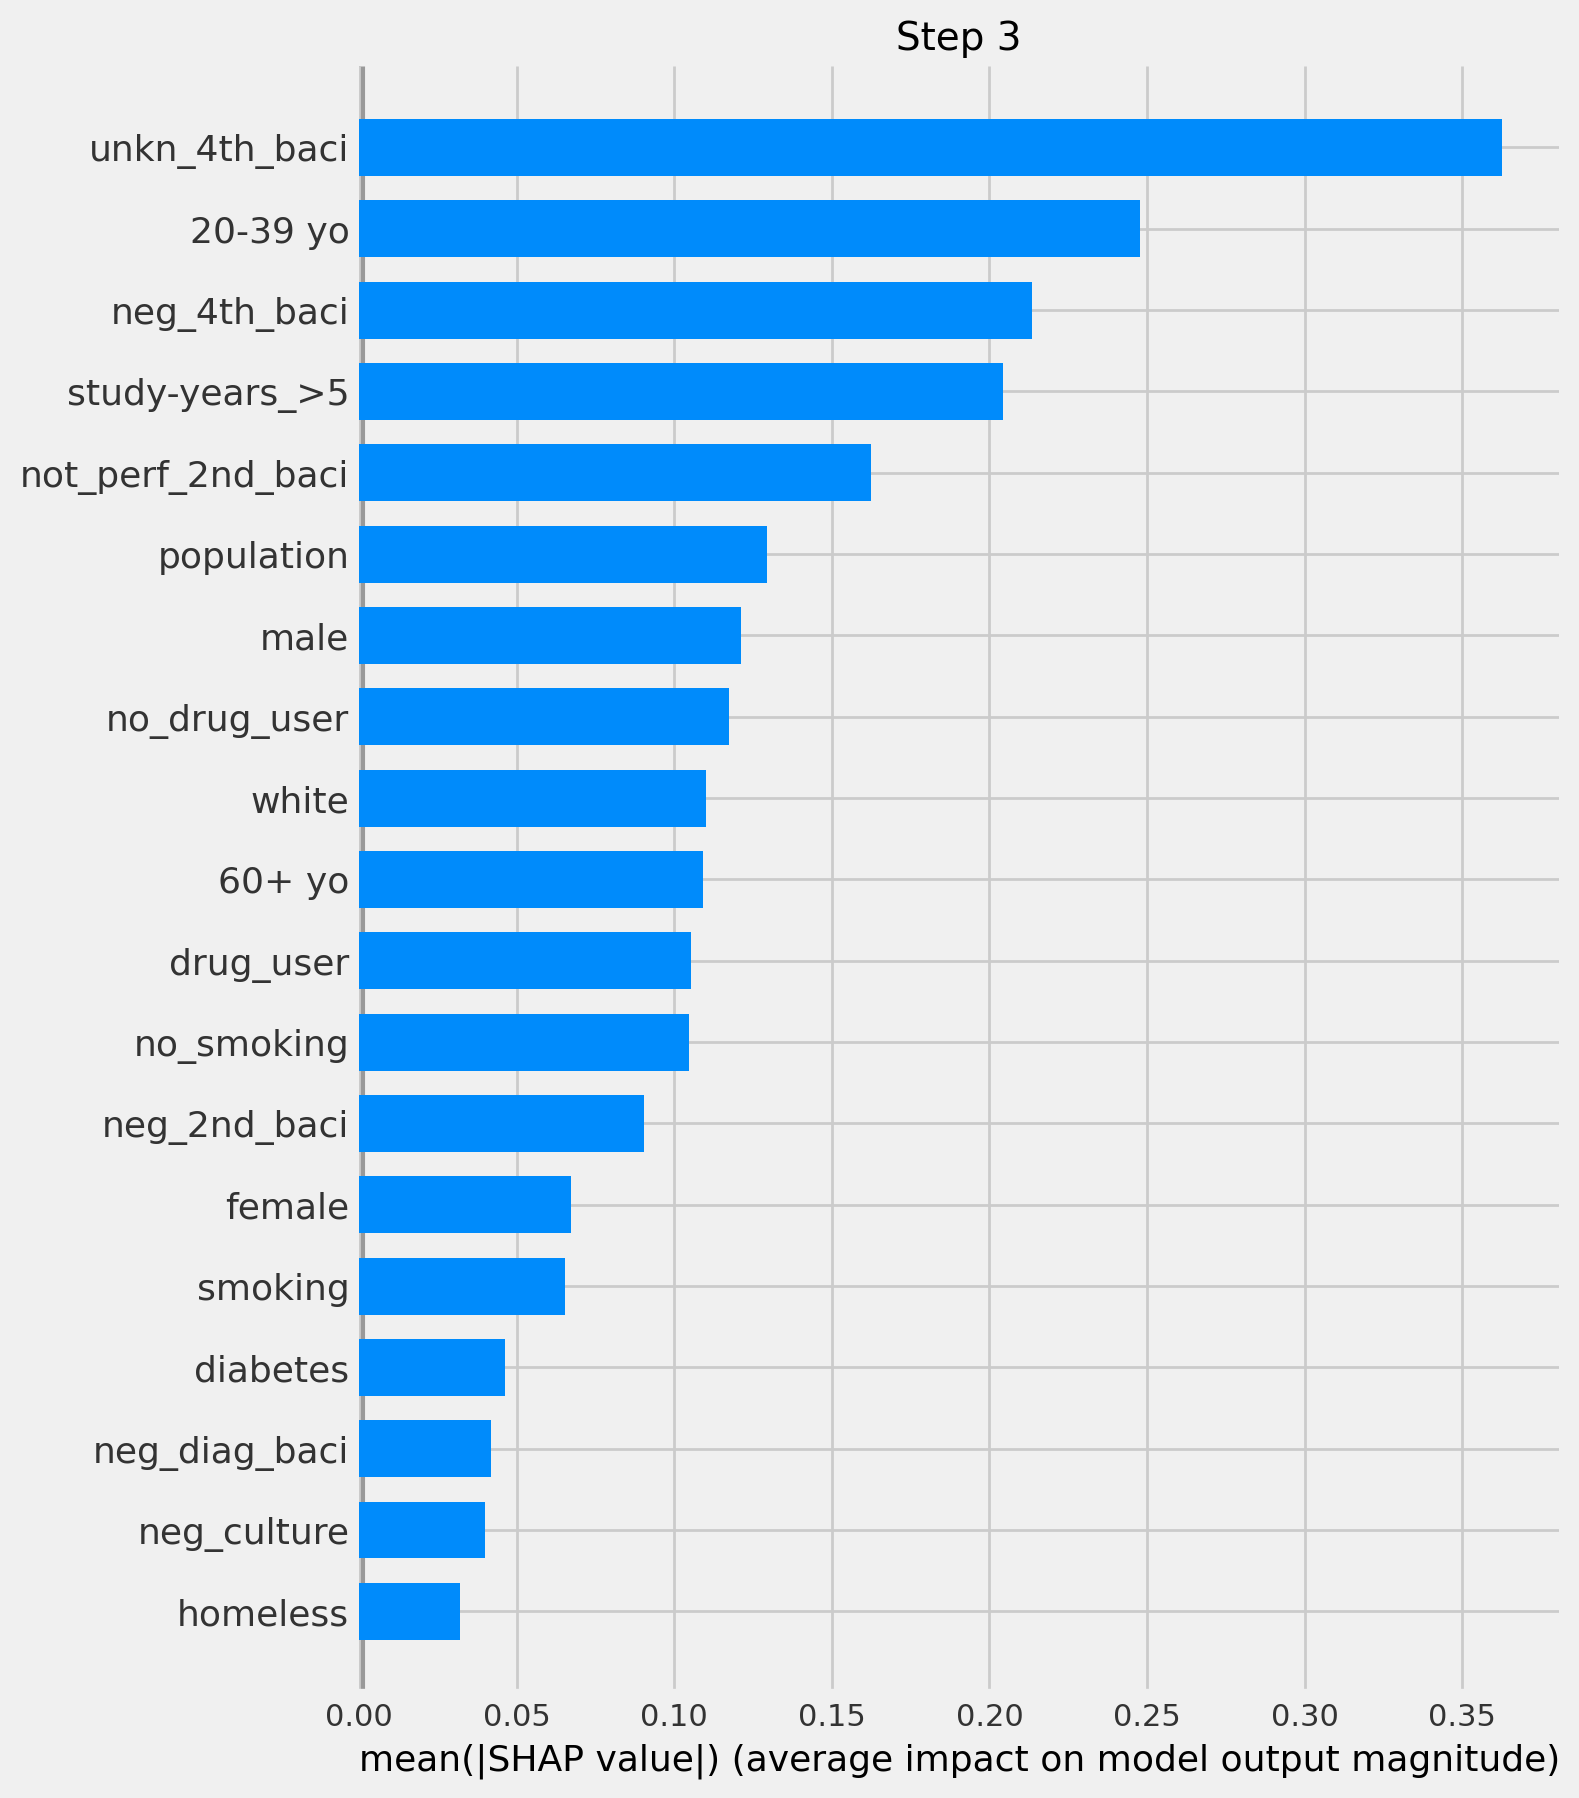

In [ ]:
import matplotlib.pyplot as plt
import shap

# =====================================================
# Renomear colunas do X_test
# =====================================================

X_test_novo4_shap = X_test_novo4.copy()

X_test_novo4_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)


# =====================================================
# Explainer SHAP
# =====================================================

explainer_cat4 = shap.TreeExplainer(
    cat_novo4
)


# Valores SHAP
shap_values_cat4 = explainer_cat4.shap_values(
    X_test_novo4
)


# =====================================================
# Summary plot
# =====================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values_cat4,
    X_test_novo4_shap,
    plot_type="bar",
    show=False
)


plt.title(
    "Step 3",
    fontsize=14
)

plt.tight_layout()


# =====================================================
# Salvar TIFF 300 dpi
# =====================================================

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step3_Global.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

###Todas as etapas

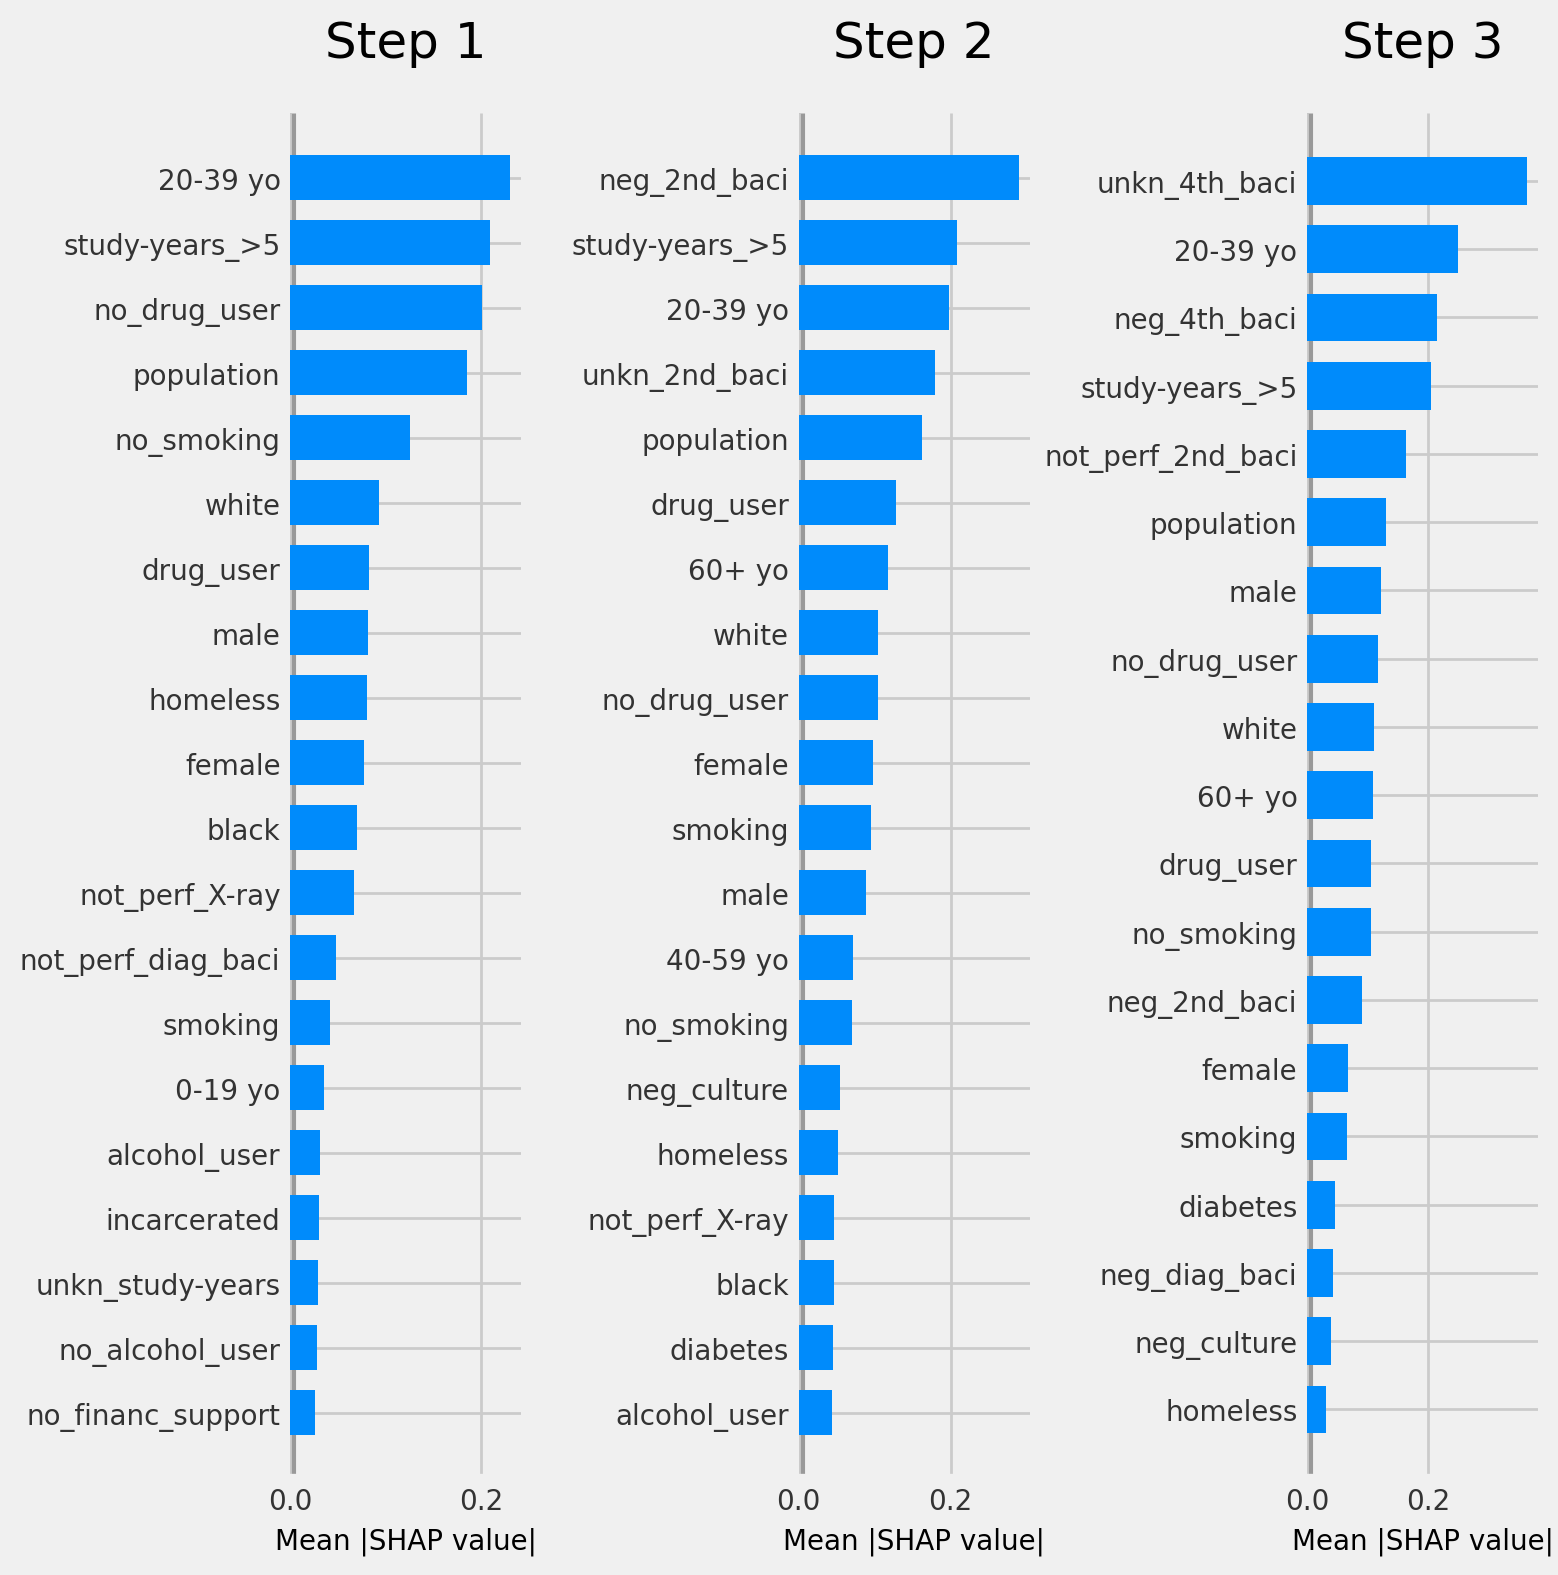

In [ ]:
import matplotlib.pyplot as plt
import shap
import textwrap

# =====================================================
# Preparar dados renomeados
# =====================================================

X_test_novo1_shap = X_test_novo1.copy()
X_test_novo1_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)

X_test_novo2_shap = X_test_novo2.copy()
X_test_novo2_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)

X_test_novo4_shap = X_test_novo4.copy()
X_test_novo4_shap.rename(
    columns=colunas_renomeadas,
    inplace=True
)

# =====================================================
# Calcular SHAP values
# =====================================================

explainer_xgb = shap.TreeExplainer(xgb_novo1)
shap_values_xgb = explainer_xgb.shap_values(
    X_test_novo1
)

explainer_cat2 = shap.TreeExplainer(cat_novo2)
shap_values_cat2 = explainer_cat2.shap_values(
    X_test_novo2
)

explainer_cat4 = shap.TreeExplainer(cat_novo4)
shap_values_cat4 = explainer_cat4.shap_values(
    X_test_novo4
)

# =====================================================
# Figura
# =====================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(100, 14)
)

# =====================================================
# Step 1
# =====================================================

plt.sca(axes[0])

shap.summary_plot(
    shap_values_xgb,
    X_test_novo1_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

axes[0].set_title(
    "Step 1",
    fontsize=18,
    pad=20
)

# =====================================================
# Step 2
# =====================================================

plt.sca(axes[1])

shap.summary_plot(
    shap_values_cat2,
    X_test_novo2_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

axes[1].set_title(
    "Step 2",
    fontsize=18,
    pad=20
)

# =====================================================
# Step 3
# =====================================================

plt.sca(axes[2])

shap.summary_plot(
    shap_values_cat4,
    X_test_novo4_shap,
    plot_type="bar",
    max_display=20,
    show=False
)

axes[2].set_title(
    "Step 3",
    fontsize=18,
    pad=20
)

# =====================================================
# Ajustes de fonte e rótulos
# =====================================================

for ax in axes:

    # Rótulos das variáveis
    labels = [lbl.get_text() for lbl in ax.get_yticklabels()]

    labels = [
        "\n".join(textwrap.wrap(label, width=18))
        for label in labels
    ]

    ax.set_yticklabels(
        labels,
        fontsize=10
    )

    # Números do eixo X
    ax.tick_params(
        axis="x",
        labelsize=10
    )

    # Texto abaixo do gráfico
    ax.set_xlabel(
        "Mean |SHAP value|",
        fontsize=10
    )

# =====================================================
# Espaçamento
# =====================================================

plt.subplots_adjust(
    left=0.20,
    right=0.98,
    top=0.90,
    bottom=0.15,
    wspace=1.20
)

# =====================================================
# Salvar TIFF
# =====================================================

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/SHAP_Global_All_Steps.tiff",
    format="tiff",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

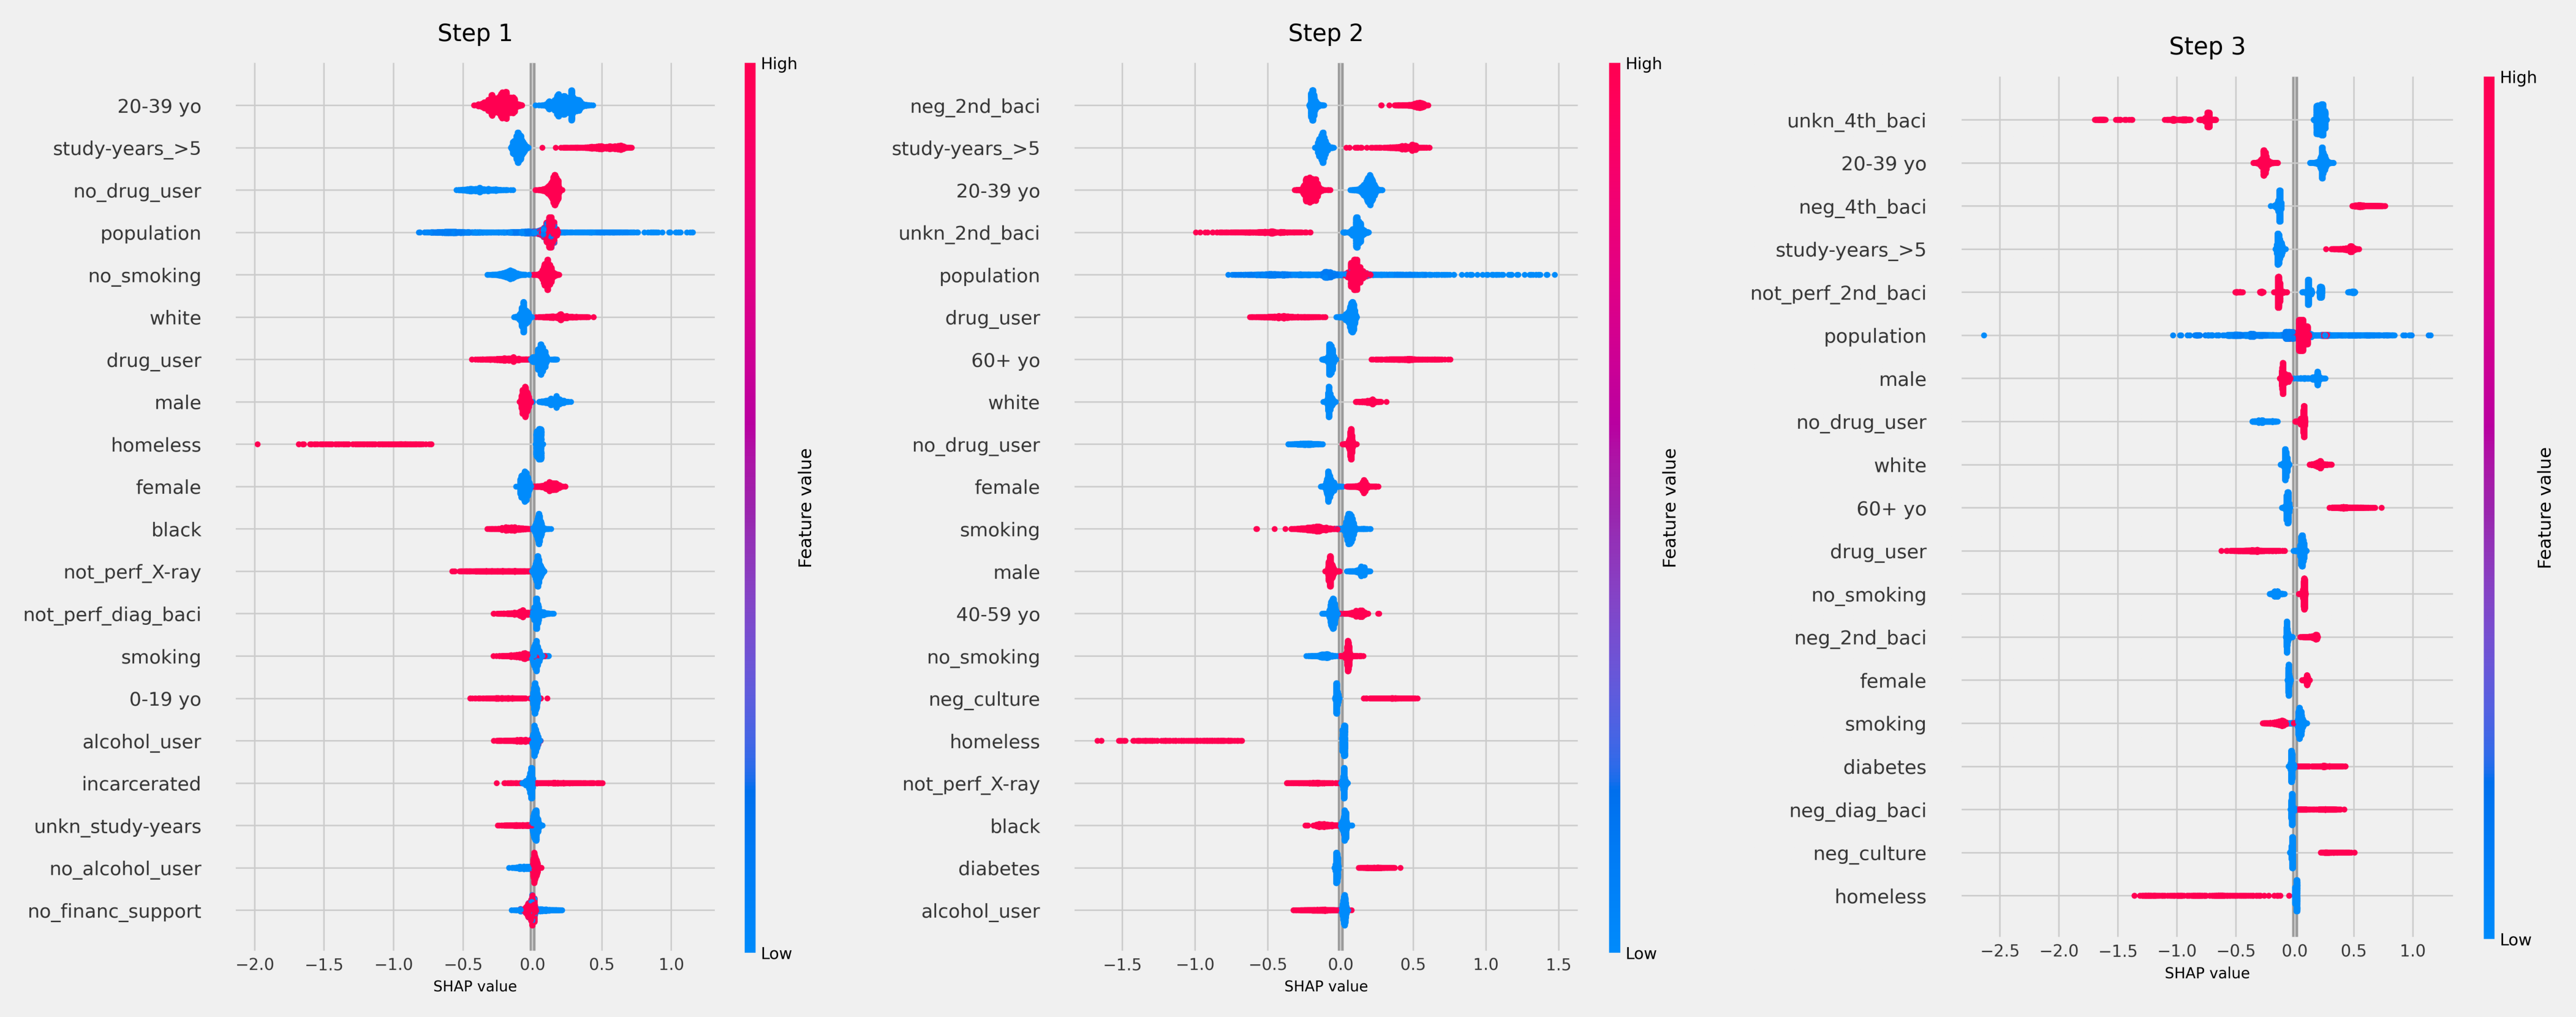

In [ ]:
import matplotlib.pyplot as plt
import shap
import numpy as np
import tempfile
import matplotlib.image as mpimg

# =====================================================
# Preparar dados renomeados
# =====================================================

X_test_novo1_shap = X_test_novo1.copy()
X_test_novo1_shap.rename(columns=colunas_renomeadas, inplace=True)

X_test_novo2_shap = X_test_novo2.copy()
X_test_novo2_shap.rename(columns=colunas_renomeadas, inplace=True)

X_test_novo4_shap = X_test_novo4.copy()
X_test_novo4_shap.rename(columns=colunas_renomeadas, inplace=True)

# =====================================================
# SHAP values
# =====================================================

explainer_xgb = shap.TreeExplainer(xgb_novo1)
shap_values_xgb = explainer_xgb.shap_values(X_test_novo1)

explainer_cat2 = shap.TreeExplainer(cat_novo2)
shap_values_cat2 = explainer_cat2.shap_values(X_test_novo2)

explainer_cat4 = shap.TreeExplainer(cat_novo4)
shap_values_cat4 = explainer_cat4.shap_values(X_test_novo4)

# =====================================================
# Função para gerar e salvar summary plot
# =====================================================

def salvar_summary_plot(shap_values, X, titulo):

    with tempfile.NamedTemporaryFile(
        suffix=".png",
        delete=False
    ) as tmp:

        plt.figure(figsize=(8, 8))

        shap.summary_plot(
            shap_values,
            X,
            max_display=20,
            show=False
        )

        plt.title(
            titulo,
            fontsize=16,
            pad=15
        )

        plt.xlabel(
            "SHAP value",
            fontsize=10
        )

        plt.tight_layout()

        plt.savefig(
            tmp.name,
            dpi=300,
            bbox_inches="tight"
        )

        plt.close()

        return tmp.name

# =====================================================
# Gerar imagens
# =====================================================

img1 = salvar_summary_plot(
    shap_values_xgb,
    X_test_novo1_shap,
    "Step 1"
)

img2 = salvar_summary_plot(
    shap_values_cat2,
    X_test_novo2_shap,
    "Step 2"
)

img3 = salvar_summary_plot(
    shap_values_cat4,
    X_test_novo4_shap,
    "Step 3"
)

# =====================================================
# Ler imagens
# =====================================================

im1 = mpimg.imread(img1)
im2 = mpimg.imread(img2)
im3 = mpimg.imread(img3)

# =====================================================
# Criar figura final com 3 painéis
# =====================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(24, 10)
)

axes[0].imshow(im1)
axes[0].axis("off")

axes[1].imshow(im2)
axes[1].axis("off")

axes[2].imshow(im3)
axes[2].axis("off")

plt.subplots_adjust(wspace=0.05)

# =====================================================
# Salvar TIFF
# =====================================================

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/SHAP_Summary_All_Steps.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.show()

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# STEP 1 - XGBoost
# =====================================================

# Probabilidade da classe positiva
probs1 = xgb_novo1.predict_proba(X_test_novo1)[:, 1]

# Índice da maior probabilidade
idx_max_1 = np.argmax(probs1)

print(f"STEP 1")
print(f"Índice: {idx_max_1}")
print(f"Maior probabilidade: {probs1[idx_max_1]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[idx_max_1],
    X_test_novo1_shap.iloc[idx_max_1],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step1_ForceMaxProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()


# =====================================================
# STEP 2 - CatBoost
# =====================================================

probs2 = cat_novo2.predict_proba(X_test_novo2)[:, 1]

idx_max_2 = np.argmax(probs2)

print(f"\nSTEP 2")
print(f"Índice: {idx_max_2}")
print(f"Maior probabilidade: {probs2[idx_max_2]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_cat2.expected_value,
    shap_values_cat2[idx_max_2],
    X_test_novo2_shap.iloc[idx_max_2],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step2_ForceMaxProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()


# =====================================================
# STEP 3 - CatBoost
# =====================================================

probs4 = cat_novo4.predict_proba(X_test_novo4)[:, 1]

idx_max_4 = np.argmax(probs4)

print(f"\nSTEP 3")
print(f"Índice: {idx_max_4}")
print(f"Maior probabilidade: {probs4[idx_max_4]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_cat4.expected_value,
    shap_values_cat4[idx_max_4],
    X_test_novo4_shap.iloc[idx_max_4],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step3_ForceMaxProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()

print("\nGráficos salvos com sucesso!")

STEP 1
Índice: 1374
Maior probabilidade: 0.9397

STEP 2
Índice: 1522
Maior probabilidade: 0.9967

STEP 3
Índice: 13229
Maior probabilidade: 0.9978

Gráficos salvos com sucesso!


<Figure size 1400x300 with 0 Axes>

<Figure size 1400x300 with 0 Axes>

<Figure size 1400x300 with 0 Axes>

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# STEP 1 - XGBoost
# =====================================================

# Probabilidade da classe positiva
probs1 = xgb_novo1.predict_proba(X_test_novo1)[:, 1]

# Índice da menor probabilidade
idx_min_1 = np.argmin(probs1)

print("STEP 1")
print(f"Índice: {idx_min_1}")
print(f"Menor probabilidade: {probs1[idx_min_1]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[idx_min_1],
    X_test_novo1_shap.iloc[idx_min_1],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step1_ForceMinProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()


# =====================================================
# STEP 2 - CatBoost
# =====================================================

probs2 = cat_novo2.predict_proba(X_test_novo2)[:, 1]

idx_min_2 = np.argmin(probs2)

print("\nSTEP 2")
print(f"Índice: {idx_min_2}")
print(f"Menor probabilidade: {probs2[idx_min_2]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_cat2.expected_value,
    shap_values_cat2[idx_min_2],
    X_test_novo2_shap.iloc[idx_min_2],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step2_ForceMinProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()


# =====================================================
# STEP 3 - CatBoost
# =====================================================

probs4 = cat_novo4.predict_proba(X_test_novo4)[:, 1]

idx_min_4 = np.argmin(probs4)

print("\nSTEP 3")
print(f"Índice: {idx_min_4}")
print(f"Menor probabilidade: {probs4[idx_min_4]:.4f}")

plt.figure(figsize=(14, 3))

shap.force_plot(
    explainer_cat4.expected_value,
    shap_values_cat4[idx_min_4],
    X_test_novo4_shap.iloc[idx_min_4],
    matplotlib=True,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/Artigo1_RJ/Step3_ForceMinProb.tiff",
    dpi=300,
    format="tiff",
    bbox_inches="tight"
)

plt.close()

print("\nGráficos salvos com sucesso!")

STEP 1
Índice: 118
Menor probabilidade: 0.0543

STEP 2
Índice: 7073
Menor probabilidade: 0.1375

STEP 3
Índice: 2452
Menor probabilidade: 0.1092

Gráficos salvos com sucesso!
